In [60]:
from app.modules.analysis import get_forest_loss, calculate_total_loss_per_year
import geemap
import ee

ImportError: cannot import name 'get_forest_loss' from 'app.modules.analysis' (C:\Python Training\ForestWatch-Analytics\app\modules\analysis.py)

In [2]:
file_path = 'C:\Python Training\ForestWatch-Analytics\yankari.geojson'
yankari = get_forest_col(file_path)
print(yankari)

GEE initialized (existing token).
Authenticated
GEE initialized (existing token).
Automatically determined UTM CRS: EPSG:32632
ee.Image({
  "functionInvocationValue": {
    "functionName": "Image.clip",
    "arguments": {
      "geometry": {
        "functionInvocationValue": {
          "functionName": "Collection.geometry",
          "arguments": {
            "collection": {
              "functionInvocationValue": {
                "functionName": "Collection",
                "arguments": {
                  "features": {
                    "arrayValue": {
                      "values": [
                        {
                          "functionInvocationValue": {
                            "functionName": "Feature",
                            "arguments": {
                              "geometry": {
                                "functionInvocationValue": {
                                  "functionName": "GeometryConstructors.Polygon",
                               

In [3]:
yankari.getInfo()['bands']

[{'id': 'treecover2000',
  'data_type': {'type': 'PixelType', 'precision': 'int', 'min': 0, 'max': 255},
  'dimensions': [3004, 2298],
  'origin': [760755, 279512],
  'crs': 'EPSG:4326',
  'crs_transform': [0.00025, 0, -180, 0, -0.00025, 80]},
 {'id': 'loss',
  'data_type': {'type': 'PixelType', 'precision': 'int', 'min': 0, 'max': 255},
  'dimensions': [3004, 2298],
  'origin': [760755, 279512],
  'crs': 'EPSG:4326',
  'crs_transform': [0.00025, 0, -180, 0, -0.00025, 80]},
 {'id': 'gain',
  'data_type': {'type': 'PixelType', 'precision': 'int', 'min': 0, 'max': 255},
  'dimensions': [3004, 2298],
  'origin': [760755, 279512],
  'crs': 'EPSG:4326',
  'crs_transform': [0.00025, 0, -180, 0, -0.00025, 80]},
 {'id': 'lossyear',
  'data_type': {'type': 'PixelType', 'precision': 'int', 'min': 0, 'max': 255},
  'dimensions': [3004, 2298],
  'origin': [760755, 279512],
  'crs': 'EPSG:4326',
  'crs_transform': [0.00025, 0, -180, 0, -0.00025, 80]},
 {'id': 'first_b30',
  'data_type': {'type': 'P

In [4]:
yankari.bandNames().getInfo()

['treecover2000',
 'loss',
 'gain',
 'lossyear',
 'first_b30',
 'first_b40',
 'first_b50',
 'first_b70',
 'last_b30',
 'last_b40',
 'last_b50',
 'last_b70',
 'datamask']

In [5]:
yankari.select('loss')

In [6]:
import ee
import geemap

# Initialize Earth Engine
ee.Initialize()

# Define visualization parameters
vis_params = {
    'bands': ['loss'],
    'min': 0,
    'max': 100,  # Adjust based on the expected tree cover percentage
    'palette': ['red', 'yellow', 'green']  # Color scale from low to high
}

# Create a map
Map = geemap.Map()
Map.addLayer(yankari.select('loss'), vis_params, "Tree Cover 2000")
Map.centerObject(yankari, 8)  # Adjust zoom level as needed
Map


Map(center=[9.843981857634265, 10.533193505000561], controls=(WidgetControl(options=['position', 'transparent_…

In [7]:
loss_2015 = yankari.select('loss').eq(15)

loss_2015_vis_params = {
    'palette': ['red']
}

Map.addLayer(loss_2015, loss_2015_vis_params, "Forest Loss in 2015")
Map

Map(bottom=31267.0, center=[9.843981857634265, 10.533193505000561], controls=(WidgetControl(options=['position…

In [8]:
sparse = loss_2015.updateMask(loss_2015.eq(15))

In [9]:
Map.addLayer(sparse, {'palette': ['red']}, "Forest Loss in 2015")
Map

Map(bottom=31267.0, center=[9.843981857634265, 10.533193505000561], controls=(WidgetControl(options=['position…

In [10]:
loss_histogram = yankari.select('loss').reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    scale=30,
    maxPixels=1e13
)

# Get the dictionary of forest loss per year
loss_dict = loss_histogram.getInfo()

print("Forest Loss Pixel Counts Per Year:", loss_dict)

Forest Loss Pixel Counts Per Year: {'loss': {'0': 3085961.760784315, '1': 57421.81568627453}}


In [11]:
loss_year = yankari.select('lossyear')

histogram = loss_year.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    # geometry=yankari.geometry(),
    scale=30,
    maxPixels=1e13
)

print("Yearly Forest Loss:", histogram.getInfo())

Yearly Forest Loss: {'lossyear': {'1': 453.19215686274515, '10': 17040.600000000002, '11': 3537.627450980392, '12': 2181.439215686274, '13': 2540.7607843137253, '14': 2708.654901960785, '15': 1680, '16': 795.3450980392157, '17': 666.6745098039215, '18': 1218.713725490196, '19': 652, '2': 601.9607843137255, '20': 206, '21': 779.521568627451, '22': 4342.811764705882, '23': 4500.321568627452, '3': 299.8862745098039, '4': 1420.207843137255, '5': 385.1372549019608, '6': 313.60392156862747, '7': 5319.85882352941, '8': 2444.635294117647, '9': 3332.862745098039}}


In [12]:
loss_year.projection()

#### Reproject forest loss data

In [13]:
# Reproject the loss_year image to EPSG:32632
loss_year_reprojected = loss_year.reproject(crs='EPSG:32632', scale=30)

# Print the new projection to confirm
crs_reprojected = loss_year_reprojected.projection()
print("Reprojected CRS:", crs_reprojected.getInfo())

# Perform the histogram calculation with the reprojected image
histogram = loss_year_reprojected.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    # geometry=yankari.geometry(),  # You can uncomment this if you want to restrict the region
    scale=30,
    maxPixels=1e13
)

print("Yearly Forest Loss (Reprojected):", histogram.getInfo())


Reprojected CRS: {'type': 'Projection', 'crs': 'EPSG:32632', 'transform': [30, 0, 0, 0, -30, 0]}
Yearly Forest Loss (Reprojected): {'lossyear': {'1': 427.47058823529403, '10': 16710.39607843137, '11': 3447.654901960784, '12': 2153.8431372549016, '13': 2423.188235294118, '14': 2654.325490196078, '15': 1629.827450980392, '16': 741.6274509803922, '17': 661.8705882352941, '18': 1164.3411764705882, '19': 672, '2': 568.7647058823529, '20': 201, '21': 750.1764705882352, '22': 4293.011764705882, '23': 4333.294117647059, '3': 293.45098039215685, '4': 1368.486274509804, '5': 387.89803921568625, '6': 315.4313725490196, '7': 5203.023529411764, '8': 2415.823529411765, '9': 3249.6862745098033}}


In [14]:


# Filter for pixels where loss occurred in 2015
loss_2015 = loss_year_reprojected.eq(15)  # Binary mask: 1 = loss in 2015, 0 = everything else

# Convert loss pixels to polygon features
loss_polygons = loss_2015.selfMask().reduceToVectors(
    geometryType='polygon',   # Extracts full polygon boundaries
    reducer=ee.Reducer.countEvery(),  # Count pixels in each polygon
    scale=30,  # Match dataset resolution
    maxPixels=1e13
)

# Print feature collection (loss polygons)
print("Loss Polygons in 2015:", loss_polygons.getInfo())

Loss Polygons in 2015: {'type': 'FeatureCollection', 'columns': {'count': 'Long<0, 4294967295>', 'label': 'Byte<0, 1>', 'system:index': 'String'}, 'features': [{'type': 'Feature', 'geometry': {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[10.276166085850637, 9.722728946577245], [10.27643952272843, 9.722727925893453], [10.276441580651966, 9.72327047373094], [10.276168143333997, 9.72327149446863], [10.276166085850637, 9.722728946577245]]]}, 'id': '+21333-35835', 'properties': {'count': 2, 'label': 1}}, {'type': 'Feature', 'geometry': {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[10.399356817601888, 9.625676412550986], [10.399630162231684, 9.625675304434168], [10.399631278990297, 9.625946566167265], [10.399357934144904, 9.625947674328998], [10.399356817601888, 9.625676412550986]]]}, 'id': '+21785-35479', 'properties': {'count': 1, 'label': 1}}, {'type': 'Feature', 'geometry': {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[10.443422497394742, 9.63905804217743

In [15]:
# Create a map object
Map = geemap.Map()

# Add loss polygons to the map
Map.addLayer(loss_polygons, {'color': 'red'}, "Forest Loss Polygons (2015)")

# Add a basemap for context
Map.add_basemap("SATELLITE")

# Display the map
Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

In [14]:
loss_year_reprojected.projection()

In [15]:
loss_year_reprojected

In [16]:
forest_lost_2015 = loss_year_reprojected.updateMask(loss_year.eq(15))

In [17]:
forest_lost_2015

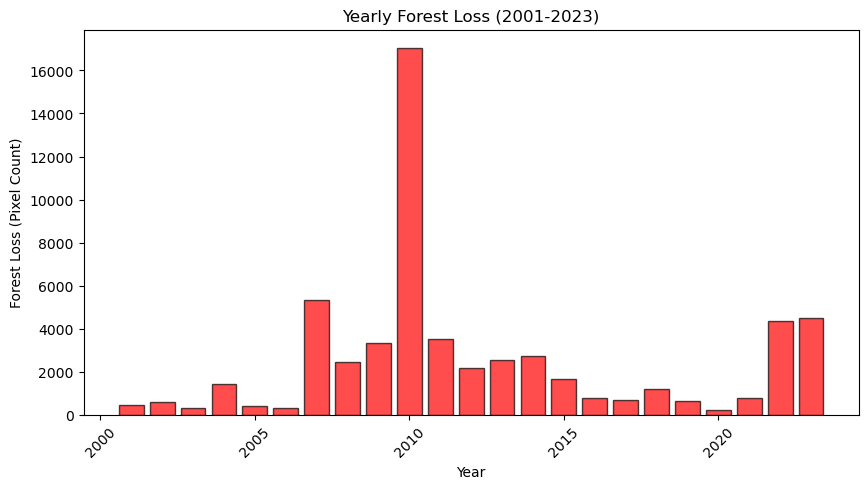

In [18]:
import matplotlib.pyplot as plt

# Extract loss year and corresponding pixel counts
loss_data = {
    '1': 453, '10': 17040, '11': 3537, '12': 2181, '13': 2540, '14': 2708, '15': 1680,
    '16': 795, '17': 666, '18': 1218, '19': 652, '20': 206, '21': 779, '22': 4342,
    '23': 4500, '2': 601, '3': 299, '4': 1420, '5': 385, '6': 313, '7': 5319,
    '8': 2444, '9': 3332
}

years = [int(k) + 2000 for k in loss_data.keys()]  # Convert to actual years (2001-2023)
loss_counts = list(loss_data.values())  # Pixel counts

# Sort the data by year (just in case)
sorted_years, sorted_counts = zip(*sorted(zip(years, loss_counts)))



### **2. Plot the Histogram**

plt.figure(figsize=(10, 5))
plt.bar(sorted_years, sorted_counts, color='red', alpha=0.7, edgecolor='black')

# Labels and Title
plt.xlabel("Year")
plt.ylabel("Forest Loss (Pixel Count)")
plt.title("Yearly Forest Loss (2001-2023)")
plt.xticks(rotation=45)  # Rotate x-axis labels for readability

plt.show()


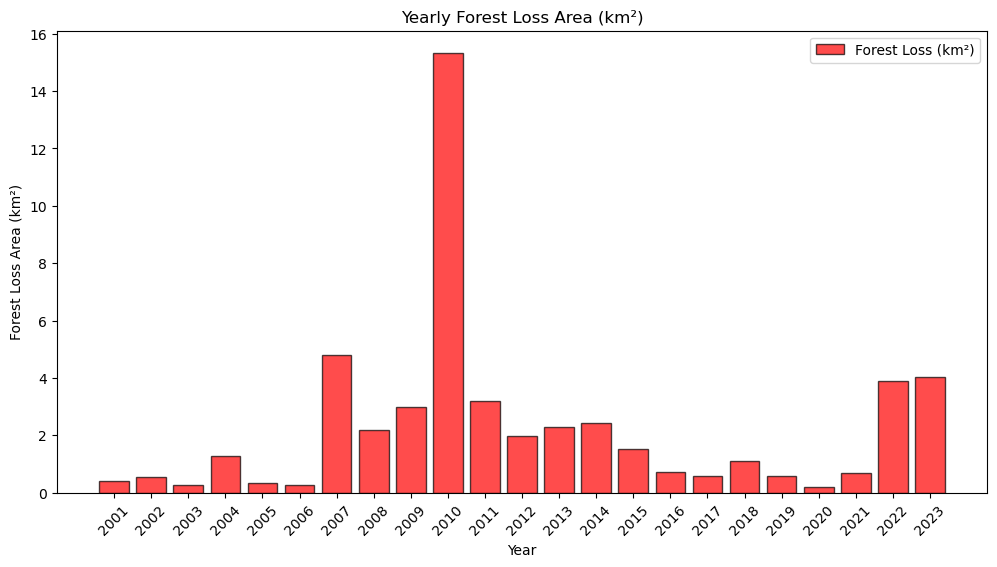

In [19]:
 import matplotlib.pyplot as plt

# Given yearly forest loss data (pixel counts)
loss_data = {
    '1': 453, '10': 17040, '11': 3537, '12': 2181, '13': 2540, '14': 2708, '15': 1680,
    '16': 795, '17': 666, '18': 1218, '19': 652, '20': 206, '21': 779, '22': 4342,
    '23': 4500, '2': 601, '3': 299, '4': 1420, '5': 385, '6': 313, '7': 5319,
    '8': 2444, '9': 3332
}

# Convert loss_data keys to actual years
loss_years = {int(k) + 2000: v for k, v in loss_data.items()}  # Convert to actual years

# Calculate area per pixel in km² (assuming 30m resolution, so each pixel is 0.0009 km²)
area_per_pixel = 0.0009  # in km²

# Calculate the forest loss area (in km²)
loss_area = {year: count * area_per_pixel for year, count in loss_years.items()}

# Generate full list of years from 2001 to 2023
all_years = list(range(2001, 2024))



# Plot missing years as "No Data"
plt.figure(figsize=(12, 6))



# Now plot the available data (forest loss area in km²)
available_years = sorted(loss_area.keys())
loss_area_values = [loss_area[year] for year in available_years]

# Plot the available data as red bars
plt.bar(available_years, loss_area_values, color='red', alpha=0.7, edgecolor='black', label="Forest Loss (km²)")

# Labels & Titles
plt.xlabel("Year")
plt.ylabel("Forest Loss Area (km²)")
plt.title("Yearly Forest Loss Area (km²)")
plt.xticks(all_years, rotation=45)  # Show all years on x-axis
plt.legend()

plt.show()


## Converrt the data to dataframe

In [20]:
# Extract the loss data from the histogram result
histogram = loss_year.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    scale=30,  # 30m resolution for UMD Hansen data
    maxPixels=1e13
)

# Convert the histogram result to a Python dictionary
loss_data_dict = histogram.getInfo()

# Print to verify
print("Yearly Forest Loss:", loss_data_dict)



Yearly Forest Loss: {'lossyear': {'1': 453.19215686274515, '10': 17040.600000000002, '11': 3537.627450980392, '12': 2181.439215686274, '13': 2540.7607843137253, '14': 2708.654901960785, '15': 1680, '16': 795.3450980392157, '17': 666.6745098039215, '18': 1218.713725490196, '19': 652, '2': 601.9607843137255, '20': 206, '21': 779.521568627451, '22': 4342.811764705882, '23': 4500.321568627452, '3': 299.8862745098039, '4': 1420.207843137255, '5': 385.1372549019608, '6': 313.60392156862747, '7': 5319.85882352941, '8': 2444.635294117647, '9': 3332.862745098039}}


### Convert the Data to a DataFrame

In [21]:
import pandas as pd

# Convert the histogram result into a pandas DataFrame
loss_years = loss_data_dict['lossyear']
df_loss = pd.DataFrame(loss_years.items(), columns=["Year", "Pixel Count"])

# Verify the DataFrame
print(df_loss.head())


  Year   Pixel Count
0    1    453.192157
1   10  17040.600000
2   11   3537.627451
3   12   2181.439216
4   13   2540.760784


#### Create GeoDataFrame for Spatial Data

In [22]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Polygon
import numpy as np

# Define the size of each pixel (30m x 30m)
pixel_size = 30  # meters

# Create polygons representing forest loss for each year
def create_polygons_for_loss(year, pixel_count):
    # Calculate the number of pixels as the side length of each polygon's square area
    area_per_pixel = pixel_size * pixel_size  # 30m * 30m = 900 square meters per pixel
    area = pixel_count * area_per_pixel  # Total area in square meters

    # Assume that the loss pixels form a square grid for simplicity (adjust as needed)
    num_side = int(np.sqrt(pixel_count))  # Taking the square root to form a square grid

    # Create a single large polygon for this loss (as an example)
    # Here, we will create a polygon with the given area (width * height) based on pixel_count
    # Assume a simple rectangular shape with the calculated dimensions
    polygon = Polygon([(0, 0), (num_side * pixel_size, 0),
                       (num_side * pixel_size, num_side * pixel_size),
                       (0, num_side * pixel_size)])

    # Create a DataFrame for the polygons
    return pd.DataFrame({
        'Year': [year],
        'geometry': [polygon]
    })

all_polygons = []

for year, pixel_count in loss_years.items():
    # Ensure `year` is treated as an integer and `pixel_count` is casted as an integer
    year_polygons = create_polygons_for_loss(int(year) + 2000, int(pixel_count))  # Adjust year
    all_polygons.append(year_polygons)

# Concatenate all the dataframes into one GeoDataFrame
gdf_loss = pd.concat(all_polygons, ignore_index=True)
gdf_loss = gpd.GeoDataFrame(gdf_loss, geometry=gdf_loss['geometry'])

gdf_loss.head()


,Year,geometry
0,2001,"POLYGON ((0.000 0.000, 630.000 0.000, 630.000 ..."
1,2010,"POLYGON ((0.000 0.000, 3900.000 0.000, 3900.00..."
2,2011,"POLYGON ((0.000 0.000, 1770.000 0.000, 1770.00..."
3,2012,"POLYGON ((0.000 0.000, 1380.000 0.000, 1380.00..."
4,2013,"POLYGON ((0.000 0.000, 1500.000 0.000, 1500.00..."


In [23]:
gdf_loss

,Year,geometry
0,2001,"POLYGON ((0.000 0.000, 630.000 0.000, 630.000 ..."
1,2010,"POLYGON ((0.000 0.000, 3900.000 0.000, 3900.00..."
2,2011,"POLYGON ((0.000 0.000, 1770.000 0.000, 1770.00..."
3,2012,"POLYGON ((0.000 0.000, 1380.000 0.000, 1380.00..."
4,2013,"POLYGON ((0.000 0.000, 1500.000 0.000, 1500.00..."
5,2014,"POLYGON ((0.000 0.000, 1560.000 0.000, 1560.00..."
6,2015,"POLYGON ((0.000 0.000, 1200.000 0.000, 1200.00..."
7,2016,"POLYGON ((0.000 0.000, 840.000 0.000, 840.000 ..."
8,2017,"POLYGON ((0.000 0.000, 750.000 0.000, 750.000 ..."
9,2018,"POLYGON ((0.000 0.000, 1020.000 0.000, 1020.00..."


In [24]:
# Reproject to a UTM zone (choose an appropriate zone based on your region)
import geopandas as gpd
gdf_loss.set_crs(epsg=32632, inplace=True)  # Set the CRS to WGS84

# Now calculate the area in square meters and then convert to square kilometers
gdf_loss['area_m2'] = gdf_loss.geometry.area
gdf_loss['area_km2'] = gdf_loss['area_m2'] / 1e6

gdf_loss.head()


,Year,geometry,area_m2,area_km2
0,2001,"POLYGON ((0.000 0.000, 630.000 0.000, 630.000 ...",396900.0,0.3969
1,2010,"POLYGON ((0.000 0.000, 3900.000 0.000, 3900.00...",15210000.0,15.2100
2,2011,"POLYGON ((0.000 0.000, 1770.000 0.000, 1770.00...",3132900.0,3.1329
3,2012,"POLYGON ((0.000 0.000, 1380.000 0.000, 1380.00...",1904400.0,1.9044
4,2013,"POLYGON ((0.000 0.000, 1500.000 0.000, 1500.00...",2250000.0,2.2500


In [27]:
# Select the 'lossyear' band
loss_year = yankari.select("lossyear")

# Filter for pixels where loss occurred in 2015
loss_2015 = loss_year.eq(16)  # Binary mask: 1 = loss in 2015, 0 = everything else

# Convert loss pixels to polygon features
loss_polygons = loss_2015.selfMask().reduceToVectors(
    geometryType='polygon',   # Extracts full polygon boundaries
    reducer=ee.Reducer.countEvery(),  # Count pixels in each polygon
    scale=30,  # Match dataset resolution
    maxPixels=1e13
)

# Print feature collection (loss polygons)
print("Loss Polygons in 2015:", loss_polygons.getInfo())

Loss Polygons in 2015: {'type': 'FeatureCollection', 'columns': {'count': 'Long<0, 4294967295>', 'label': 'Byte<0, 1>', 'system:index': 'String'}, 'features': [{'type': 'Feature', 'geometry': {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[10.192300100597635, 9.926556936143072], [10.192569595182874, 9.926556936143072], [10.192569595182874, 9.927095925313537], [10.192300100597635, 9.927095925313537], [10.192300100597635, 9.927365419898777], [10.192030606012395, 9.927365419898777], [10.192030606012395, 9.926826430728312], [10.192300100597635, 9.926826430728312], [10.192300100597635, 9.926556936143072]]]}, 'id': '+705737+260017', 'properties': {'count': 4, 'label': 1}}, {'type': 'Feature', 'geometry': {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[10.192839089768114, 9.924400979461183], [10.193108584353354, 9.924400979461183], [10.193108584353354, 9.924670474046422], [10.192839089768114, 9.924670474046422], [10.192839089768114, 9.924400979461183]]]}, 'id': '+705739+2600

In [28]:
# Create a map object
Map = geemap.Map()

# Add loss polygons to the map
Map.addLayer(loss_polygons, {'color': 'red'}, "Forest Loss Polygons (2015)")

# Add a basemap for context
Map.add_basemap("SATELLITE")

# Display the map
Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…